In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio

In [2]:
meta=np.load(r'C:\Users\Darkrai\Projects\iitk proj\ERA5_DATABASE\site_264967_802413\metadata_pressure.npz')
plds=np.load(r'C:\Users\Darkrai\Projects\iitk proj\ERA5_DATABASE\site_264967_802413\pressure_2025.npz')
sds=np.load(r'C:\Users\Darkrai\Projects\iitk proj\ERA5_DATABASE\site_264967_802413\surface_2025.npz')
dem_src=rasterio.open(r'C:\Users\Darkrai\Projects\iitk proj\DEMs\Kanpur\Kanpur_90.tif')
elevation_data=dem_src.read(1)
g=9.80655

In [3]:
target_lat=cp.asarray(meta['target_lat'])
target_lon=cp.asarray(meta['target_lon'])
nearest_lat=cp.asarray(meta['nearest_lat'])
nearest_lon=cp.asarray(meta['nearest_lon'])
lat = cp.asarray(meta["tile_latitudes"])
lon = cp.asarray(meta["tile_longitudes"])
t=cp.asarray(plds['temperature'])
q=cp.asarray(plds['specific_humidity'])
z=cp.asarray(plds['geopotential'])/g
levels=cp.asarray(meta['pressure_levels'])

In [4]:
dem_src.bounds

BoundingBox(left=78.49958330000001, bottom=24.500416699999995, right=82.49958330000001, top=28.500416699999995)

In [5]:
tile_lat = meta["tile_latitudes"]
tile_lon = meta["tile_longitudes"]
west  = tile_lon.min()
east  = tile_lon.max()

south = tile_lat.min()
north = tile_lat.max()
from shapely.geometry import box, mapping
from rasterio.mask import mask

# ERA5 tile bounds
west  = float(tile_lon.min())
east  = float(tile_lon.max())
south = float(tile_lat.min())
north = float(tile_lat.max())

# Bounding box polygon
bbox = box(west, south, east, north)

# Crop DEM
cropped_dem, cropped_transform = mask(
    dem_src,
    [mapping(bbox)],
    crop=True
)

# Remove band dimension
cropped_dem = cropped_dem[0]

print(cropped_dem.shape)

(3000, 2701)


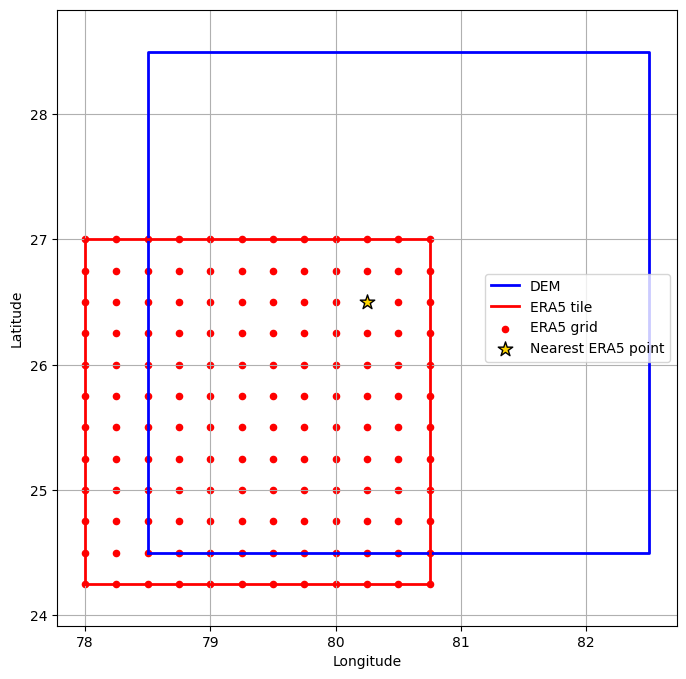

In [6]:
#dem comparison with era5 grid
import matplotlib.pyplot as plt
import rasterio

# DEM bounds
bounds = dem_src.bounds

dem_lon = [bounds.left, bounds.right]
dem_lat = [bounds.bottom, bounds.top]

# ERA5 tile
tile_lat = meta["tile_latitudes"]
tile_lon = meta["tile_longitudes"]

nearest_lat = float(meta["nearest_lat"])
nearest_lon = float(meta["nearest_lon"])

plt.figure(figsize=(8,8))

# DEM rectangle
plt.plot(
    [bounds.left, bounds.right, bounds.right, bounds.left, bounds.left],
    [bounds.bottom, bounds.bottom, bounds.top, bounds.top, bounds.bottom],
    'b-', lw=2, label='DEM'
)

# ERA5 tile rectangle
plt.plot(
    [tile_lon.min(), tile_lon.max(), tile_lon.max(), tile_lon.min(), tile_lon.min()],
    [tile_lat.min(), tile_lat.min(), tile_lat.max(), tile_lat.max(), tile_lat.min()],
    'r-', lw=2, label='ERA5 tile'
)

# ERA5 grid points
LON, LAT = np.meshgrid(tile_lon, tile_lat)

plt.scatter(
    LON,
    LAT,
    s=20,
    color='red',
    label='ERA5 grid'
)

# nearest point
plt.scatter(
    nearest_lon,
    nearest_lat,
    s=120,
    marker='*',
    color='gold',
    edgecolor='black',
    label='Nearest ERA5 point'
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.axis("equal")
plt.grid(True)

plt.show()

In [7]:
row,col=dem_src.index(target_lon.get(),target_lat.get())
small_box=cropped_dem[row-80:row+80,col-80:col+80]


In [8]:
lat_idx = int(cp.argmin(cp.abs(lat - target_lat)))
lon_idx = int(cp.argmin(cp.abs(lon - target_lon)))

print(lat_idx, lon_idx)
print(lat[lat_idx], lon[lon_idx])

2 9
26.5 80.25


In [68]:
z=z[::3,:,lat_idx,lon_idx]
q=q[::3,:,lat_idx,lon_idx]
t=t[::3,:,lat_idx,lon_idx]
np.save(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\temp.npy',t)

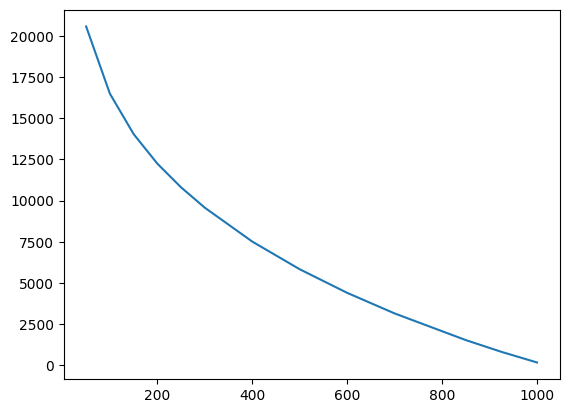

In [69]:
plt.plot(levels.get(),z[1,:].get())

In [70]:
dem_linear=cropped_dem.flatten()
dem_linear.shape

(8103000,)

In [71]:
small_box_flat=cp.asarray(small_box.flatten())
insert_idx=((z[:,:,None]<small_box_flat).sum(axis=1)).astype(np.uint8)
insert_idx=insert_idx.reshape(insert_idx.shape[0],small_box.shape[0],small_box.shape[1])
np.save(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\insert_idx.npy',insert_idx)

In [72]:
del small_box_flat
del cropped_dem

In [73]:
small_box=cp.asarray(small_box)

In [74]:
pk=cp.log(levels[insert_idx-1]*100)
pk_1=cp.log(levels[insert_idx]*100)
rows = cp.arange(z.shape[0])[:, None, None]

z0 = z[rows, insert_idx-1]
z1 = z[rows, insert_idx]
ratio=(small_box-z0)/(z1-z0)
ps=cp.exp(pk+ratio*(pk_1-pk))
T = ps.shape[0]
H, W = ps.shape[1:]
np.save(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\ps.npy',ps)
np.save(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\ratio.npy',ratio)
del ratio
del ps


In [75]:
#checking all variables
import sys
import numpy as np
import cupy as cp

sizes = []

for name, obj in list(globals().items()):   # <-- make a copy
    try:
        if isinstance(obj, np.ndarray):
            size = obj.nbytes
        elif isinstance(obj, cp.ndarray):
            size = obj.nbytes
        else:
            size = sys.getsizeof(obj)

        sizes.append((name, size))
    except Exception:
        pass

# Sort from largest to smallest
sizes.sort(key=lambda x: x[1], reverse=True)

for name, size in sizes:
    print(f"{name:20s}: {size/1024**2:10.2f} MB")

p_surface           :     570.31 MB
pk                  :     570.31 MB
pk_1                :     570.31 MB
vmr_surface         :     285.16 MB
t_surface           :     285.16 MB
z0                  :     285.16 MB
z1                  :     285.16 MB
elevation_data      :      87.89 MB
insert_idx          :      71.29 MB
horizon_elev        :      35.16 MB
max_zenith          :      35.16 MB
horizon             :      35.16 MB
max_za              :      35.16 MB
dem_linear          :      30.91 MB
pred                :      23.08 MB
Tb_pred             :      23.08 MB
X                   :       5.72 MB
X_norm              :       5.72 MB
profiles            :       4.20 MB
ps_c                :       3.91 MB
ratio_c             :       1.95 MB
ps_q                :       0.20 MB
inverse             :       0.20 MB
Ps                  :       0.20 MB
pixel_to_profile    :       0.20 MB
t                   :       0.14 MB
q                   :       0.14 MB
z                   :       

In [76]:
del z0
del pk
del z1
del pk_1

In [77]:
#calculate pwv
import cupy as cp
import numpy as np

levels = levels.astype(cp.float32)
levels_pa = levels * 100.0          # <-- convert once



chunk_size = 100

pwv = np.empty((T, H, W), dtype=np.float32)
qs_all = np.empty((T, H, W), dtype=np.float32)
ps=cp.load(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\ps.npy')
ratio=cp.load(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\ratio.npy')
for start in range(0, T, chunk_size):

    end = min(start + chunk_size, T)
    t_len = end - start

    idx     = insert_idx[start:end]     # (t,H,W)
    ps_c    = ps[start:end]             # Pa
    q_c     = q[start:end]              # (t,13)
    ratio_c = ratio[start:end]          # (t,H,W)

    # -------------------------------------------------------
    # Surface humidity
    # -------------------------------------------------------

    t_idx3 = cp.arange(t_len).reshape(t_len,1,1)

    q0 = q_c[t_idx3, idx-1]
    q1 = q_c[t_idx3, idx]

    qs = q0 + ratio_c*(q1-q0)
    # Save surface specific humidity
    qs_all[start:end] = cp.asnumpy(qs)
    del q0, q1

    # -------------------------------------------------------
    # Build shifted source index
    # -------------------------------------------------------

    k_arr = cp.arange(14, dtype=idx.dtype).reshape(1,1,1,14)

    shift = (k_arr > idx[...,None]).astype(idx.dtype)

    src = cp.clip(k_arr-shift,0,12)

    del shift, k_arr

    t_idx4 = cp.arange(t_len).reshape(t_len,1,1,1)

    # -------------------------------------------------------
    # Pressure interfaces (ALL IN Pa)
    # -------------------------------------------------------

    out = levels_pa[src]

    q_full = q_c[t_idx4,src]

    del src, t_idx4

    cp.put_along_axis(
        out,
        idx[...,None],
        ps_c[...,None],
        axis=3
    )

    cp.put_along_axis(
        q_full,
        idx[...,None],
        qs[...,None],
        axis=3
    )

    

    # -------------------------------------------------------
    # Integrate
    # -------------------------------------------------------

    dp = cp.abs(out[...,1:] - out[...,:-1])      # <-- already Pa

    avg_q = 0.5*(q_full[...,1:] + q_full[...,:-1])

    del out, q_full

    k13 = cp.arange(13,dtype=idx.dtype).reshape(1,1,1,13)

    mask = k13 >= idx[...,None]

    del k13, idx

    integral = cp.sum(
        cp.where(mask,avg_q*dp,0.0),
        axis=-1
    )

    del dp, avg_q, mask

    pwv[start:end] = cp.asnumpy(integral)

    del integral

    cp._default_memory_pool.free_all_blocks()

    print(f"done {end}/{T}", end="\r")

del ratio
del ps
del qs
np.save(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\pwv.npy',pwv/g)
np.save(r"C:\Users\Darkrai\Projects\iitk proj\Derived_things\qs.npy",qs_all)
del qs_all
print("\nsaved", pwv.shape)

done 2920/2920
saved (2920, 160, 160)


In [78]:
# import cupy as cp
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.animation as animation

# # Copy every 10th frame to CPU
# frames = cp.asnumpy(pwv[::10])   # Shape: (879, 200, 200)

# # Global color limits (same for every frame)
# vmin = np.nanmin(frames)
# vmax = np.nanmax(frames)

# print(f"Global min = {vmin:.2f}")
# print(f"Global max = {vmax:.2f}")
# print(f"Range      = {vmax-vmin:.2f}")

# fig, ax = plt.subplots(figsize=(6, 6))

# im = ax.imshow(
#     frames[0],
#     cmap="terrain",
#     origin="lower",
#     vmin=vmin,
#     vmax=vmax
# )

# cbar = fig.colorbar(im, ax=ax)
# cbar.set_label("PWV")

# title = ax.set_title("Frame 0")
# ax.axis("off")


# def update(i):
#     im.set_data(frames[i])
#     title.set_text(f"Frame {i*10}")
#     return im, title


# ani = animation.FuncAnimation(
#     fig,
#     update,
#     frames=len(frames),
#     interval=100,
#     blit=False
# )

# ani.save("pwv_2000.mp4", writer="ffmpeg", fps=30, dpi=150)

# print("Saved as surface_pressure.mp4")

In [79]:
del pwv

Calculated PWV
 Mean : 36.11561
 Min  : 4.513122
 Max  : 80.162224

ERA5 TCWV
 Mean : 34.194244
 Min  : 5.12387
 Max  : 78.2482

Bias = 1.921366
RMSE = 5.1432962
Correlation = 0.9777647216977653


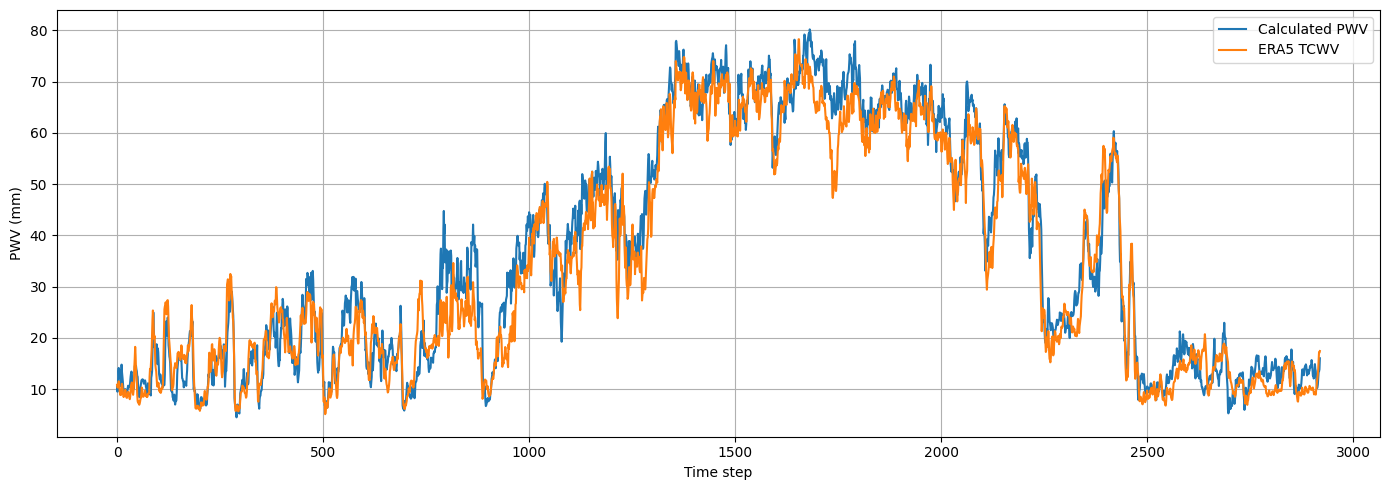

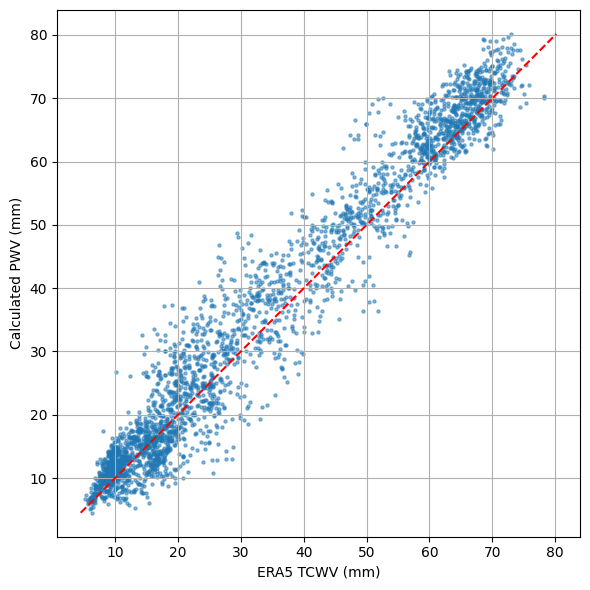

In [80]:
#comparison to tcwv
import numpy as np
import matplotlib.pyplot as plt

g = 9.80665

# -----------------------------
# Load calculated PWV
# -----------------------------
pwv_mm = np.load(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\pwv.npy')       # shape (T,H,W)



# Spatial average over DEM
mean_pwv = pwv_mm.mean(axis=(1,2))

# -----------------------------
# ERA5 TCWV
# -----------------------------
# Same ERA5 grid point you've been using
era5_tcwv = sds["tcwv"][::3, 8, 3]

# -----------------------------
# Statistics
# -----------------------------
print("Calculated PWV")
print(" Mean :", mean_pwv.mean())
print(" Min  :", mean_pwv.min())
print(" Max  :", mean_pwv.max())

print("\nERA5 TCWV")
print(" Mean :", era5_tcwv.mean())
print(" Min  :", era5_tcwv.min())
print(" Max  :", era5_tcwv.max())

print("\nBias =", np.mean(mean_pwv - era5_tcwv))
print("RMSE =", np.sqrt(np.mean((mean_pwv-era5_tcwv)**2)))
print("Correlation =",
      np.corrcoef(mean_pwv, era5_tcwv)[0,1])

# -----------------------------
# Time series
# -----------------------------
plt.figure(figsize=(14,5))

plt.plot(mean_pwv,label="Calculated PWV")
plt.plot(era5_tcwv,label="ERA5 TCWV")

plt.xlabel("Time step")
plt.ylabel("PWV (mm)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# Scatter plot
# -----------------------------
plt.figure(figsize=(6,6))

plt.scatter(era5_tcwv, mean_pwv, s=5, alpha=0.5)

m = min(era5_tcwv.min(), mean_pwv.min())
M = max(era5_tcwv.max(), mean_pwv.max())

plt.plot([m,M],[m,M],'r--')

plt.xlabel("ERA5 TCWV (mm)")
plt.ylabel("Calculated PWV (mm)")
plt.grid(True)

plt.tight_layout()
plt.show()
del pwv_mm
del insert_idx

In [81]:
#checking all variables
import sys
import numpy as np
import cupy as cp

sizes = []

for name, obj in list(globals().items()):   # <-- make a copy
    try:
        if isinstance(obj, np.ndarray):
            size = obj.nbytes
        elif isinstance(obj, cp.ndarray):
            size = obj.nbytes
        else:
            size = sys.getsizeof(obj)

        sizes.append((name, size))
    except Exception:
        pass

# Sort from largest to smallest
sizes.sort(key=lambda x: x[1], reverse=True)

for name, size in sizes:
    print(f"{name:20s}: {size/1024**2:10.2f} MB")

p_surface           :     570.31 MB
vmr_surface         :     285.16 MB
t_surface           :     285.16 MB
elevation_data      :      87.89 MB
horizon_elev        :      35.16 MB
max_zenith          :      35.16 MB
horizon             :      35.16 MB
max_za              :      35.16 MB
dem_linear          :      30.91 MB
pred                :      23.08 MB
Tb_pred             :      23.08 MB
X                   :       5.72 MB
X_norm              :       5.72 MB
profiles            :       4.20 MB
ps_c                :       3.91 MB
ratio_c             :       1.95 MB
ps_q                :       0.20 MB
inverse             :       0.20 MB
Ps                  :       0.20 MB
pixel_to_profile    :       0.20 MB
t                   :       0.14 MB
q                   :       0.14 MB
z                   :       0.14 MB
vmr                 :       0.14 MB
temp                :       0.14 MB
small_box           :       0.10 MB
ts                  :       0.10 MB
vmrs                :       

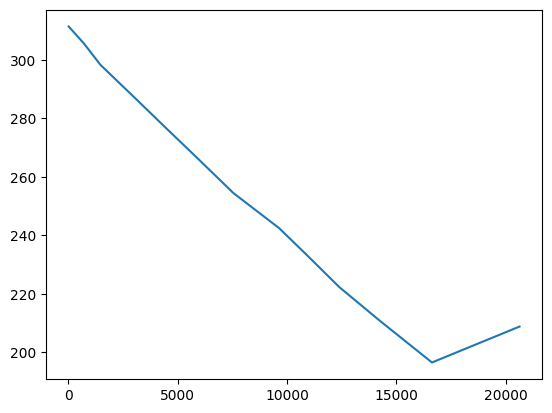

In [82]:
plt.plot(z[900].get(),t[900].get())

In [83]:
ps=np.load(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\ps.npy')
np.argmin(ps)
del ps

In [84]:
insert_idx=cp.load(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\insert_idx.npy')
ratio=cp.load(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\ratio.npy')
t0 = t[rows, insert_idx-1]
t1 = t[rows, insert_idx]
ts = t0 + ratio * (t1 - t0)
del t0,t1,ratio
np.save(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\ts.npy',ts)

In [85]:
epsilon=0.622
vmr=q/(epsilon+(1-epsilon)*q)
np.save(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\vmr_q',vmr)
del vmr

In [86]:
qs=np.load(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\qs.npy')
np.save(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\vmr_surface',qs/(epsilon+(1-epsilon)*qs))
del qs

In [87]:
del ts

In [88]:
ps=np.load(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\ps.npy')
ts=np.load(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\ts.npy')
vmrs=np.load(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\vmr_surface.npy')

In [89]:
#check profile
ps=ps[900]
ts=ts[900]
vmrs= vmrs[900]
ps.shape


(160, 160)

In [90]:
print(np.min(vmrs),np.max(vmrs),np.std(vmrs))
print(np.min(ps),np.max(ps),np.std(ps))
print(np.min(ts),np.max(ts),np.std(ts))


0.005835087 0.006702084 6.0875685e-05
95385.41522661544 98855.7181439672 245.63311795736587
307.9667 310.64798 0.18829165


In [91]:
import numpy as np

# ----------------------------------------------------
# Quantization steps
# ----------------------------------------------------

P_step = 2.5     # Pa
T_step = 0.005      # K
VMR_step = 5e-6   # volume mixing ratio

# ----------------------------------------------------
# Quantize
# ----------------------------------------------------

ps_q  = np.round(ps   / P_step)   * P_step
ts_q  = np.round(ts   / T_step)   * T_step
vmr_q = np.round(vmrs / VMR_step) * VMR_step

# ----------------------------------------------------
# Stack profiles
# ----------------------------------------------------

profiles = np.column_stack((
    ps_q.ravel(),
    ts_q.ravel(),
    vmr_q.ravel()
))

unique_profiles, inverse, counts = np.unique(
    profiles,
    axis=0,
    return_inverse=True,
    return_counts=True
)

print("="*60)
print("Pressure step :",P_step,"Pa")
print("Temp step     :",T_step,"K")
print("VMR step      :",VMR_step)
print("-"*60)
print("Total pixels  :",profiles.shape[0])
print("Unique        :",len(unique_profiles))
print("Reduction     :",profiles.shape[0]/len(unique_profiles))
print("="*60)

Pressure step : 2.5 Pa
Temp step     : 0.005 K
VMR step      : 5e-06
------------------------------------------------------------
Total pixels  : 25600
Unique        : 942
Reduction     : 27.176220806794056


In [92]:
np.min(vmr_q)

np.float32(0.005835)

<Axes: >

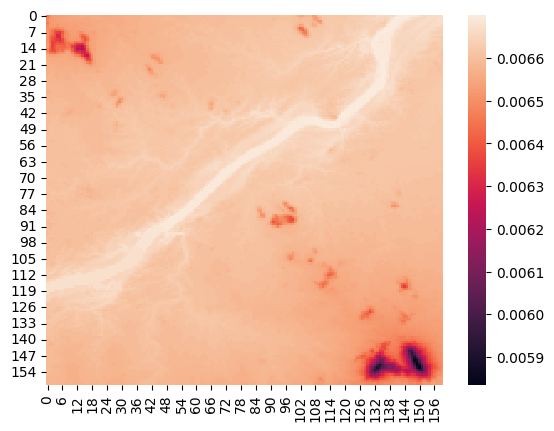

In [93]:
sns.heatmap(vmr_q)

In [94]:
f=open(r'C:\Users\Darkrai\Projects\iitk proj\first_amc.amc','w')
f.write(f'f 2 GHz 14 GHz 0.01 GHz\n')
f.write(f'T0 2.7 K\n')
f.write(f'za 0 deg\n')
for i in range(100):
    f.write(f'layer\n')
    f.write(f'Pbase {ps_q[0,0]+i} Pa\n')
    f.write(f'Tbase {ts_q[0,0]} K\n')
    f.write('column dry_air hydrostatic\n')
    f.write(f'column h2o vmr {vmr_q[1,1]}\n')
f.flush()

In [95]:
vmr_surface=np.load(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\vmr_surface.npy')
p_surface=np.load(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\ps.npy')
t_surface=np.load(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\ts.npy')
# levels=levels
# insert_idx=insert_idx
vmr=np.load(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\vmr_q.npy')
temp=np.load(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\temp.npy')
insert_idx=np.load(r'C:\Users\Darkrai\Projects\iitk proj\Derived_things\insert_idx.npy')



In [96]:
t_surface.shape

(2920, 160, 160)

In [97]:
print(vmr.shape,vmr_surface.shape,p_surface.shape,temp.shape,t_surface.shape, insert_idx.shape)

(2920, 13) (2920, 160, 160) (2920, 160, 160) (2920, 13) (2920, 160, 160) (2920, 160, 160)


In [98]:
import os
import numpy as np
import cupy as cp

insert_idx = cp.asnumpy(insert_idx)

# ==========================================================
# INPUTS
# ==========================================================

levels = meta["pressure_levels"] * 100.0   # Pa

outdir = r"C:\Users\Darkrai\Projects\iitk proj\amc_files"
os.makedirs(outdir, exist_ok=True)

timestep = 0

idx = insert_idx[timestep]

Ps = p_surface[timestep]
Ts = t_surface[timestep]
Qs = vmr_surface[timestep]

Tera = temp[timestep]
Qera = vmr[timestep]

H, W = Ps.shape

# ==========================================================
# BUILD ATMOSPHERES
# ==========================================================

# columns:
# 0          -> insertion index
# 1:15       -> pressure
# 15:29      -> temperature
# 29:43      -> vmr

profiles = np.empty((H * W, 43), dtype=np.float32)

k = 0

for i in range(H):
    for j in range(W):

        ins = int(idx[i, j])

        p = np.insert(levels, ins, Ps[i, j])
        t = np.insert(Tera,  ins, Ts[i, j])
        q = np.insert(Qera,  ins, Qs[i, j])

        profiles[k, 0] = ins
        profiles[k, 1:15] = p
        profiles[k,15:29] = t
        profiles[k,29:43] = q

        k += 1

# ==========================================================
# QUANTIZATION
# ==========================================================

Pstep = 50.0
Tstep = 1
Qstep = 2e-4

profiles[:,1:15]  = np.round(profiles[:,1:15]/Pstep)*Pstep
profiles[:,15:29] = np.round(profiles[:,15:29]/Tstep)*Tstep
profiles[:,29:43] = np.round(profiles[:,29:43]/Qstep)*Qstep

# ==========================================================
# UNIQUE
# ==========================================================

unique_profiles, inverse = np.unique(
    profiles,
    axis=0,
    return_inverse=True
)

print("="*60)
print("Pixels :", H*W)
print("Unique :", len(unique_profiles))
print("Reduction :", (H*W)/len(unique_profiles))
print("="*60)

np.save(
    os.path.join(outdir, "pixel_to_profile.npy"),
    inverse.reshape(H, W)
)

# ==========================================================
# WRITE AMC FILES
# ==========================================================

for n, prof in enumerate(unique_profiles):

    ins = int(prof[0])

    P = prof[1:15]
    T = prof[15:29]
    Q = prof[29:43]

    filename = os.path.join(outdir, f"atm_{n:06d}.amc")

    with open(filename, "w") as f:

        f.write("f 2 GHz 14 GHz 0.1 GHz\n")
        f.write("output f GHz tx Tb K\n")
        f.write("T0 2.7 K\n")
        f.write("za 0 deg\n\n")

        # only atmosphere ABOVE surface
        P_use = P[ins:]
        T_use = T[ins:]
        Q_use = Q[ins:]

        # top -> bottom
        for p, t, q in zip(P_use[::-1], T_use[::-1], Q_use[::-1]):

            f.write("layer\n")
            f.write(f"Pbase {p:.1f} Pa\n")
            f.write(f"Tbase {t:.6f} K\n")
            f.write("column dry_air hydrostatic\n")
            f.write(f"column h2o vmr {q:.10e}\n\n")

print(f"\nWritten {len(unique_profiles)} AMC files.")

Pixels : 25600
Unique : 85
Reduction : 301.1764705882353

Written 85 AMC files.


In [99]:
import os
import subprocess
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed

# ==========================================================
# SETTINGS
# ==========================================================

AM_EXE = r"C:\Users\Darkrai\Projects\iitk proj\am.exe"
AMC_DIR = r"C:\Users\Darkrai\Projects\iitk proj\amc_files"

N_WORKERS = 8          # use 8-16 if your CPU allows
MAX_RETRIES = 3

# ==========================================================
# FIND AMC FILES
# ==========================================================

amc_files = sorted(
    os.path.join(AMC_DIR, f)
    for f in os.listdir(AMC_DIR)
    if f.endswith(".amc")
)

print(f"Found {len(amc_files)} atmospheres")

# ==========================================================
# RUN AM
# ==========================================================

def run_am(amc_path):

    result = subprocess.run(
        [AM_EXE, amc_path],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        encoding="utf-8",
        errors="ignore"
    )

    rows = []

    for line in result.stdout.splitlines():

        line = line.strip()

        if not line:
            continue

        if line[0] in "#!?":
            continue

        cols = line.split()

        if len(cols) < 3:
            continue

        try:
            rows.append([
                float(cols[0]),
                float(cols[1]),
                float(cols[2])
            ])
        except:
            pass

    if len(rows) == 0:
        return None

    rows = np.asarray(rows,dtype=np.float32)

    return (
        os.path.basename(amc_path),
        rows[:,0],
        rows[:,1],
        rows[:,2]
    )

# ==========================================================
# PARALLEL PASS
# ==========================================================

results = {}
failed = []

with ThreadPoolExecutor(max_workers=N_WORKERS) as executor:

    futures = {
        executor.submit(run_am,f):f
        for f in amc_files
    }

    finished = 0

    for future in as_completed(futures):

        finished += 1

        if finished % 100 == 0 or finished == len(amc_files):
            print(f"{finished}/{len(amc_files)}")

        out = future.result()

        if out is None:
            failed.append(futures[future])
            continue

        name,freq,tau,tb = out

        results[name]=(freq,tau,tb)

print()
print("Failed after parallel pass:",len(failed))

# ==========================================================
# RETRY FAILED ONES SERIAL
# ==========================================================

still_failed=[]

for f in failed:

    success=False

    for _ in range(MAX_RETRIES):

        out=run_am(f)

        if out is not None:

            name,freq,tau,tb=out

            results[name]=(freq,tau,tb)

            success=True

            break

    if not success:
        still_failed.append(f)
        print("FAILED:",os.path.basename(f))

print()
print("Still failed:",len(still_failed))

# ==========================================================
# BUILD ARRAYS
# ==========================================================

frequency=None

tau_all=[]
tb_all=[]
valid=[]

for path in amc_files:

    name=os.path.basename(path)

    if name not in results:
        continue

    freq,tau,tb=results[name]

    if frequency is None:
        frequency=freq

    tau_all.append(tau)
    tb_all.append(tb)
    valid.append(name)

tau_all=np.asarray(tau_all,dtype=np.float32)
tb_all=np.asarray(tb_all,dtype=np.float32)

# ==========================================================
# SAVE
# ==========================================================

np.save(os.path.join(AMC_DIR,"frequency.npy"),frequency)
np.save(os.path.join(AMC_DIR,"transmittance.npy"),tau_all)
np.save(os.path.join(AMC_DIR,"brightness_temperature.npy"),tb_all)
np.save(os.path.join(AMC_DIR,"valid_files.npy"),np.array(valid))

print()
print("="*60)
print("Finished")
print("="*60)
print("Expected atmospheres :",len(amc_files))
print("Recovered            :",len(valid))
print("Missing              :",len(amc_files)-len(valid))
print("Tau shape            :",tau_all.shape)
print("Tb shape             :",tb_all.shape)
print("Tau range            :",tau_all.min(),tau_all.max())
print("Tb range             :",tb_all.min(),tb_all.max())
print("="*60)

Found 85 atmospheres
85/85

Failed after parallel pass: 0

Still failed: 0

Finished
Expected atmospheres : 85
Recovered            : 85
Missing              : 0
Tau shape            : (85, 121)
Tb shape             : (85, 121)
Tau range            : 0.9841687 0.9922237
Tb range             : 4.755686 6.96426


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# LOAD RESULTS
# ==========================================================

am_dir = r"C:\Users\Darkrai\Projects\iitk proj\amc_files"

frequency = np.load(am_dir + r"\frequency.npy")
tau = np.load(am_dir + r"\transmittance.npy")
pixel_to_profile = np.load(am_dir + r"\pixel_to_profile.npy")

# ==========================================================
# SELECT FREQUENCY
# ==========================================================

target_freq = 2   # GHz

freq_idx = np.argmin(np.abs(frequency - target_freq))

print(f"Requested frequency : {target_freq:.3f} GHz")
print(f"Nearest frequency   : {frequency[freq_idx]:.3f} GHz")
print(f"Channel index       : {freq_idx}")

# ==========================================================
# RECONSTRUCT DEM MAP
# ==========================================================

tau_map = tau[pixel_to_profile, freq_idx]

print("Tau map shape :", tau_map.shape)

# ==========================================================
# PLOT
# ==========================================================

plt.figure(figsize=(8,7))

im = plt.imshow(
    tau_map,
    origin="lower",
    cmap="viridis"
)

plt.colorbar(im, label="Transmittance")

plt.title(f"Atmospheric Transmittance @ {frequency[freq_idx]:.2f} GHz")
plt.xlabel("X Pixel")
plt.ylabel("Y Pixel")

plt.tight_layout()
plt.show()

Requested frequency : 2.000 GHz
Nearest frequency   : 2.000 GHz
Channel index       : 0


IndexError: index 270 is out of bounds for axis 0 with size 85

In [101]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.animation as animation

# # ==========================================================
# # LOAD
# # ==========================================================

# am_dir = r"C:\Users\Darkrai\Projects\iitk proj\amc_files"

# frequency = np.load(am_dir + r"\frequency.npy")
# tb = np.load(am_dir + r"\brightness_temperature.npy")
# pixel_to_profile = np.load(am_dir + r"\pixel_to_profile.npy")

# # ==========================================================
# # GLOBAL COLOR SCALE
# # ==========================================================

# vmin = tb.min()
# vmax = tb.max()

# print("Tb range:", vmin, vmax)

# # ==========================================================
# # FIGURE
# # ==========================================================

# fig, ax = plt.subplots(figsize=(8,7))

# tb_map = tb[pixel_to_profile,0]

# im = ax.imshow(
#     tb_map,
#     origin="lower",
#     vmin=vmin,
#     vmax=vmax,
#     cmap="terrain",
#     animated=True
# )

# cbar = plt.colorbar(im, ax=ax)
# cbar.set_label("Brightness Temperature (K)")

# title = ax.set_title(f"{frequency[0]:.2f} GHz")

# ax.set_xlabel("X Pixel")
# ax.set_ylabel("Y Pixel")

# # ==========================================================
# # UPDATE FUNCTION
# # ==========================================================

# def update(frame):

#     tb_map = tb[pixel_to_profile, frame]

#     im.set_array(tb_map)

#     title.set_text(
#         f"Brightness Temperature @ {frequency[frame]:.2f} GHz"
#     )

#     return im, title

# # ==========================================================
# # ANIMATION
# # ==========================================================

# ani = animation.FuncAnimation(
#     fig,
#     update,
#     frames=len(frequency),
#     interval=20,
#     blit=True
# )

# # ==========================================================
# # SAVE
# # ==========================================================

# writer = animation.FFMpegWriter(fps=30)

# ani.save(
#     "brightness_temperature_vs_frequency.mp4",
#     writer=writer,
#     dpi=150
# )

# plt.close(fig)

# print("Saved brightness_temperature_vs_frequency.mp4")

In [102]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.animation as animation

# # ==========================================================
# # LOAD
# # ==========================================================

# am_dir = r"C:\Users\Darkrai\Projects\iitk proj\amc_files"

# frequency = np.load(am_dir + r"\frequency.npy")
# tau = np.load(am_dir + r"\transmittance.npy")
# pixel_to_profile = np.load(am_dir + r"\pixel_to_profile.npy")

# # ==========================================================
# # GLOBAL COLOR SCALE
# # ==========================================================

# vmin = tau.min()
# vmax = tau.max()

# print("Transmittance range:", vmin, vmax)

# # ==========================================================
# # FIGURE
# # ==========================================================

# fig, ax = plt.subplots(figsize=(8,7))

# tau_map = tau[pixel_to_profile, 0]

# im = ax.imshow(
#     tau_map,
#     origin="lower",
#     vmin=vmin,
#     vmax=vmax,
#     cmap="viridis",
#     animated=True
# )

# cbar = plt.colorbar(im, ax=ax)
# cbar.set_label("Transmittance")

# title = ax.set_title(f"{frequency[0]:.2f} GHz")

# ax.set_xlabel("X Pixel")
# ax.set_ylabel("Y Pixel")

# # ==========================================================
# # UPDATE FUNCTION
# # ==========================================================

# def update(frame):

#     tau_map = tau[pixel_to_profile, frame]

#     im.set_array(tau_map)

#     title.set_text(
#         f"Transmittance @ {frequency[frame]:.2f} GHz"
#     )

#     return im, title

# # ==========================================================
# # ANIMATION
# # ==========================================================

# ani = animation.FuncAnimation(
#     fig,
#     update,
#     frames=len(frequency),
#     interval=20,
#     blit=True
# )

# # ==========================================================
# # SAVE
# # ==========================================================

# writer = animation.FFMpegWriter(fps=30)

# ani.save(
#     "transmittance_vs_frequency.mp4",
#     writer=writer,
#     dpi=150
# )

# plt.close(fig)

# print("Saved transmittance_vs_frequency.mp4")

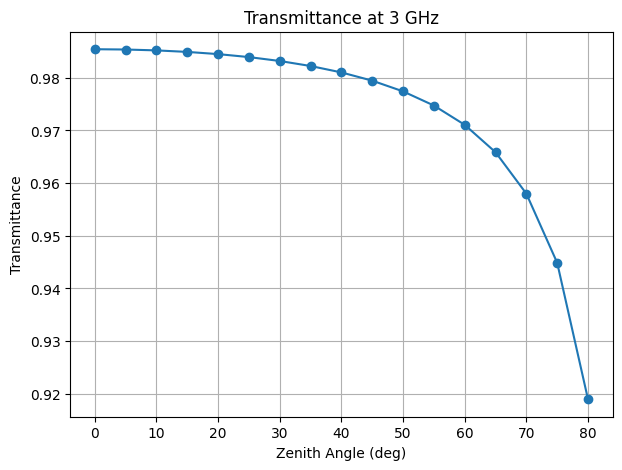

In [103]:
import os
import shutil
import subprocess
import numpy as np
import matplotlib.pyplot as plt

AM_EXE = r"C:\Users\Darkrai\Projects\iitk proj\am.exe"

base_amc = r"C:\Users\Darkrai\Projects\iitk proj\first_amc.amc"

outdir = r"C:\Users\Darkrai\Projects\iitk proj\za_test"
os.makedirs(outdir, exist_ok=True)

za_values = np.arange(0,81,5)

tx = []

for za in za_values:

    amc = os.path.join(outdir,f"za_{za:02d}.amc")

    with open(base_amc,"r") as f:
        lines=f.readlines()

    with open(amc,"w") as f:

        replaced=False

        for line in lines:

            if line.strip().startswith("za"):

                f.write(f"za {za} deg\n")
                replaced=True

            else:
                f.write(line)

        if not replaced:
            f.write(f"\nza {za} deg\n")

    result=subprocess.run(
        [AM_EXE,amc],
        stdout=subprocess.PIPE,
        text=True,
        encoding="utf-8",
        errors="ignore"
    )

    rows=[]

    for line in result.stdout.splitlines():

        line=line.strip()

        if len(line)==0:
            continue

        if line[0] in "#!?":
            continue

        cols=line.split()

        if len(cols)<3:
            continue

        rows.append([
            float(cols[0]),
            float(cols[1]),
            float(cols[2])
        ])

    rows=np.asarray(rows)

    idx=np.argmin(np.abs(rows[:,0]-3.0))

    tx.append(rows[idx,1])

tx=np.asarray(tx)

plt.figure(figsize=(7,5))

plt.plot(
    za_values,
    tx,
    "-o"
)

plt.xlabel("Zenith Angle (deg)")
plt.ylabel("Transmittance")
plt.title("Transmittance at 3 GHz")
plt.grid(True)

plt.show()

Using: C:\Users\Darkrai\Projects\iitk proj\amc_files\atm_000000.amc
Created 90 AMC files.

Successful runs: 90


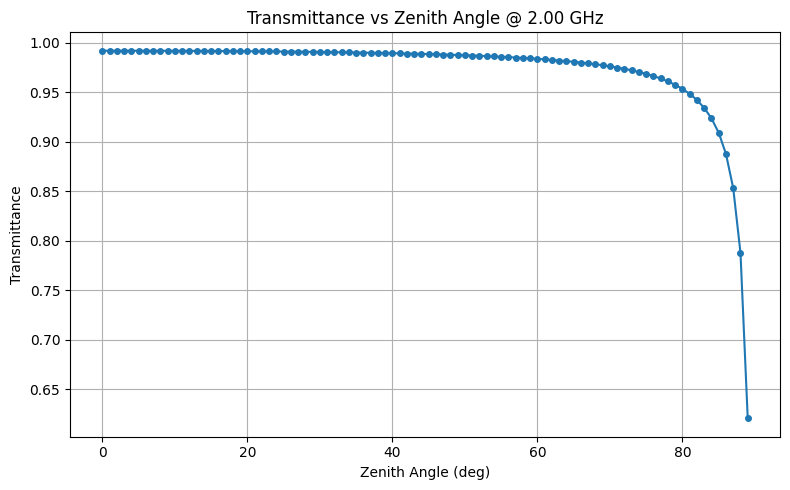

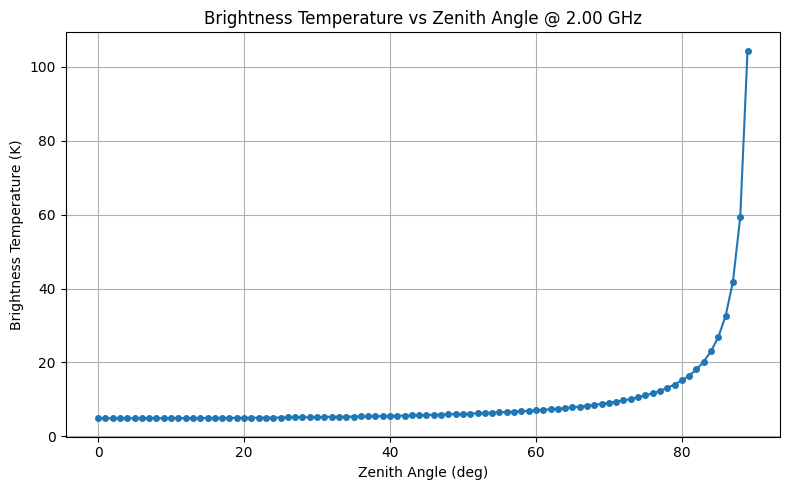

In [104]:
import os
import subprocess
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# SETTINGS
# ==========================================================

AM_EXE = r"C:\Users\Darkrai\Projects\iitk proj\am.exe"

AMC_DIR = r"C:\Users\Darkrai\Projects\iitk proj\amc_files"

ZA_DIR = os.path.join(AMC_DIR, "za_test")
os.makedirs(ZA_DIR, exist_ok=True)

TARGET_FREQ = 2.0     # GHz
ZA_MAX = 89             # Don't use 90°

# ==========================================================
# FIND FIRST AMC FILE
# ==========================================================

amc_files = sorted(
    f for f in os.listdir(AMC_DIR)
    if f.endswith(".amc")
)

if len(amc_files) == 0:
    raise RuntimeError("No AMC files found.")

base_amc = os.path.join(AMC_DIR, amc_files[0])

print("Using:", base_amc)

with open(base_amc, "r") as f:
    base_lines = f.readlines()

# ==========================================================
# CREATE ZA FILES
# ==========================================================

za_values = np.arange(0, ZA_MAX + 1, 1)

for za in za_values:

    outfile = os.path.join(ZA_DIR, f"za_{za:02d}.amc")

    replaced = False

    with open(outfile, "w") as f:

        for line in base_lines:

            if line.strip().startswith("za"):

                f.write(f"za {za} deg\n")
                replaced = True

            else:
                f.write(line)

        if not replaced:
            f.write(f"\nza {za} deg\n")

print(f"Created {len(za_values)} AMC files.")

# ==========================================================
# RUN AM
# ==========================================================

tx = []
tb = []
used_za = []

for za in za_values:

    amc = os.path.join(ZA_DIR, f"za_{za:02d}.amc")

    result = subprocess.run(
        [AM_EXE, amc],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        encoding="utf-8",
        errors="ignore"
    )

    rows = []

    for line in result.stdout.splitlines():

        line = line.strip()

        if not line:
            continue

        if line[0] in "#!?":
            continue

        cols = line.split()

        if len(cols) < 3:
            continue

        try:

            rows.append([
                float(cols[0]),
                float(cols[1]),
                float(cols[2])
            ])

        except:
            pass

    if len(rows) == 0:

        print("=" * 60)
        print(f"FAILED AT ZA = {za}")
        print("STDERR:")
        print(result.stderr)
        print("STDOUT:")
        print(result.stdout)
        print("=" * 60)

        continue

    rows = np.asarray(rows, dtype=np.float32)

    freq = rows[:,0]

    idx = np.argmin(np.abs(freq - TARGET_FREQ))

    used_za.append(za)
    tx.append(rows[idx,1])
    tb.append(rows[idx,2])

tx = np.asarray(tx)
tb = np.asarray(tb)
used_za = np.asarray(used_za)

print()
print("Successful runs:", len(used_za))

# ==========================================================
# PLOT TRANSMITTANCE
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    used_za,
    tx,
    "-o",
    markersize=4
)

plt.grid(True)

plt.xlabel("Zenith Angle (deg)")
plt.ylabel("Transmittance")

plt.title(
    f"Transmittance vs Zenith Angle @ {TARGET_FREQ:.2f} GHz"
)

plt.tight_layout()

plt.show()

# ==========================================================
# PLOT BRIGHTNESS TEMPERATURE
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    used_za,
    tb,
    "-o",
    markersize=4
)

plt.grid(True)

plt.xlabel("Zenith Angle (deg)")
plt.ylabel("Brightness Temperature (K)")

plt.title(
    f"Brightness Temperature vs Zenith Angle @ {TARGET_FREQ:.2f} GHz"
)

plt.tight_layout()

plt.show()

In [105]:
import time
import math
from pathlib import Path

import numpy as np
import rasterio
from numba import njit, prange

# ==========================================================
# CONFIG
# ==========================================================


OUT_DIR = Path(r"C:\Users\Darkrai\Projects\iitk proj\horizon_out")
OUT_DIR.mkdir(parents=True, exist_ok=True)

PIXEL_SIZE_M = 90.0
N_AZ = 360
EARTH_RADIUS_M = 6371000.0
USE_CURVATURE = True

# ==========================================================
# LOAD DEM
# ==========================================================


dem=small_box.get()
H, W = dem.shape
print("DEM shape:", dem.shape)
print("DEM range:", np.nanmin(dem), np.nanmax(dem))

# ==========================================================
# HORIZON SOLVER
# ==========================================================

@njit(parallel=True, fastmath=True)
def compute_horizon_cube(dem, pixel_size_m, n_az, earth_radius_m, use_curvature):
    H, W = dem.shape
    horizon = np.zeros((H, W, n_az), dtype=np.float32)

    for si in prange(H):
        for sj in range(W):
            h0 = dem[si, sj]

            if np.isnan(h0):
                for a in range(n_az):
                    horizon[si, sj, a] = np.nan
                continue

            local = np.zeros(n_az, dtype=np.float32)

            for ti in range(H):
                dy = (si - ti) * pixel_size_m

                for tj in range(W):
                    if ti == si and tj == sj:
                        continue

                    h = dem[ti, tj]
                    if np.isnan(h):
                        continue

                    dx = (tj - sj) * pixel_size_m
                    dist2 = dx * dx + dy * dy

                    if dist2 <= 0.0:
                        continue

                    dz = h - h0

                    if use_curvature:
                        dz -= dist2 / (2.0 * earth_radius_m)

                    if dz <= 0.0:
                        continue

                    az = math.degrees(math.atan2(dx, dy))
                    if az < 0.0:
                        az += 360.0

                    bin_idx = int(az + 0.5)
                    if bin_idx >= n_az:
                        bin_idx -= n_az

                    dist = math.sqrt(dist2)
                    slope_deg = math.degrees(math.atan2(dz, dist))

                    if slope_deg > local[bin_idx]:
                        local[bin_idx] = slope_deg

            for a in range(n_az):
                horizon[si, sj, a] = local[a]

    return horizon

# ==========================================================
# RUN
# ==========================================================

t0 = time.perf_counter()

horizon_elev = compute_horizon_cube(
    dem,
    PIXEL_SIZE_M,
    N_AZ,
    EARTH_RADIUS_M,
    USE_CURVATURE
)

elapsed = time.perf_counter() - t0
print(f"Computed horizon cube in {elapsed:.2f} s")
print("horizon_elev shape:", horizon_elev.shape)

# ==========================================================
# DERIVED MAX ZENITH ANGLE
# ==========================================================

# Horizon elevation is measured above the local horizontal.
# Maximum observable zenith angle = 90° - horizon_elevation
max_zenith = 90.0 - horizon_elev

# If a bin never had a blocking point, horizon_elev stays 0,
# so max_zenith becomes 90° (all the way to the horizon).
max_zenith = np.clip(max_zenith, 0.0, 90.0).astype(np.float32)

# ==========================================================
# SAVE
# ==========================================================

np.save(OUT_DIR / "horizon_elevation_deg.npy", horizon_elev.astype(np.float32))
np.save(OUT_DIR / "max_zenith_angle_deg.npy", max_zenith)

# Save map of "best possible" horizon and zenith per pixel
min_horizon = np.nanmin(horizon_elev, axis=2).astype(np.float32)
best_zenith = np.nanmax(max_zenith, axis=2).astype(np.float32)

np.save(OUT_DIR / "min_horizon_deg.npy", min_horizon)
np.save(OUT_DIR / "best_zenith_deg.npy", best_zenith)

print("Saved:")
print("  horizon_elevation_deg.npy")
print("  max_zenith_angle_deg.npy")
print("  min_horizon_deg.npy")
print("  best_zenith_deg.npy")

# ==========================================================
# QUICK CHECK FOR ONE PIXEL
# ==========================================================

i0, j0 = H // 2, W // 2
print("\nSample pixel:", i0, j0)
print("Elevation:", dem[i0, j0])
print("Min horizon:", min_horizon[i0, j0])
print("Best zenith:", best_zenith[i0, j0])

DEM shape: (160, 160)
DEM range: 118.5 440.38834
Computed horizon cube in 2.04 s
horizon_elev shape: (160, 160, 360)
Saved:
  horizon_elevation_deg.npy
  max_zenith_angle_deg.npy
  min_horizon_deg.npy
  best_zenith_deg.npy

Sample pixel: 80 80
Elevation: 150.32486
Min horizon: 0.0
Best zenith: 90.0


In [106]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# LOAD
# ==========================================================

horizon = np.load(r"C:\Users\Darkrai\Projects\iitk proj\horizon_out\horizon_elevation_deg.npy")
max_za  = np.load(r"C:\Users\Darkrai\Projects\iitk proj\horizon_out\max_zenith_angle_deg.npy")

print(horizon.shape)

(160, 160, 360)


Horizon cube : (160, 160, 360)
Max ZA cube  : (160, 160, 360)


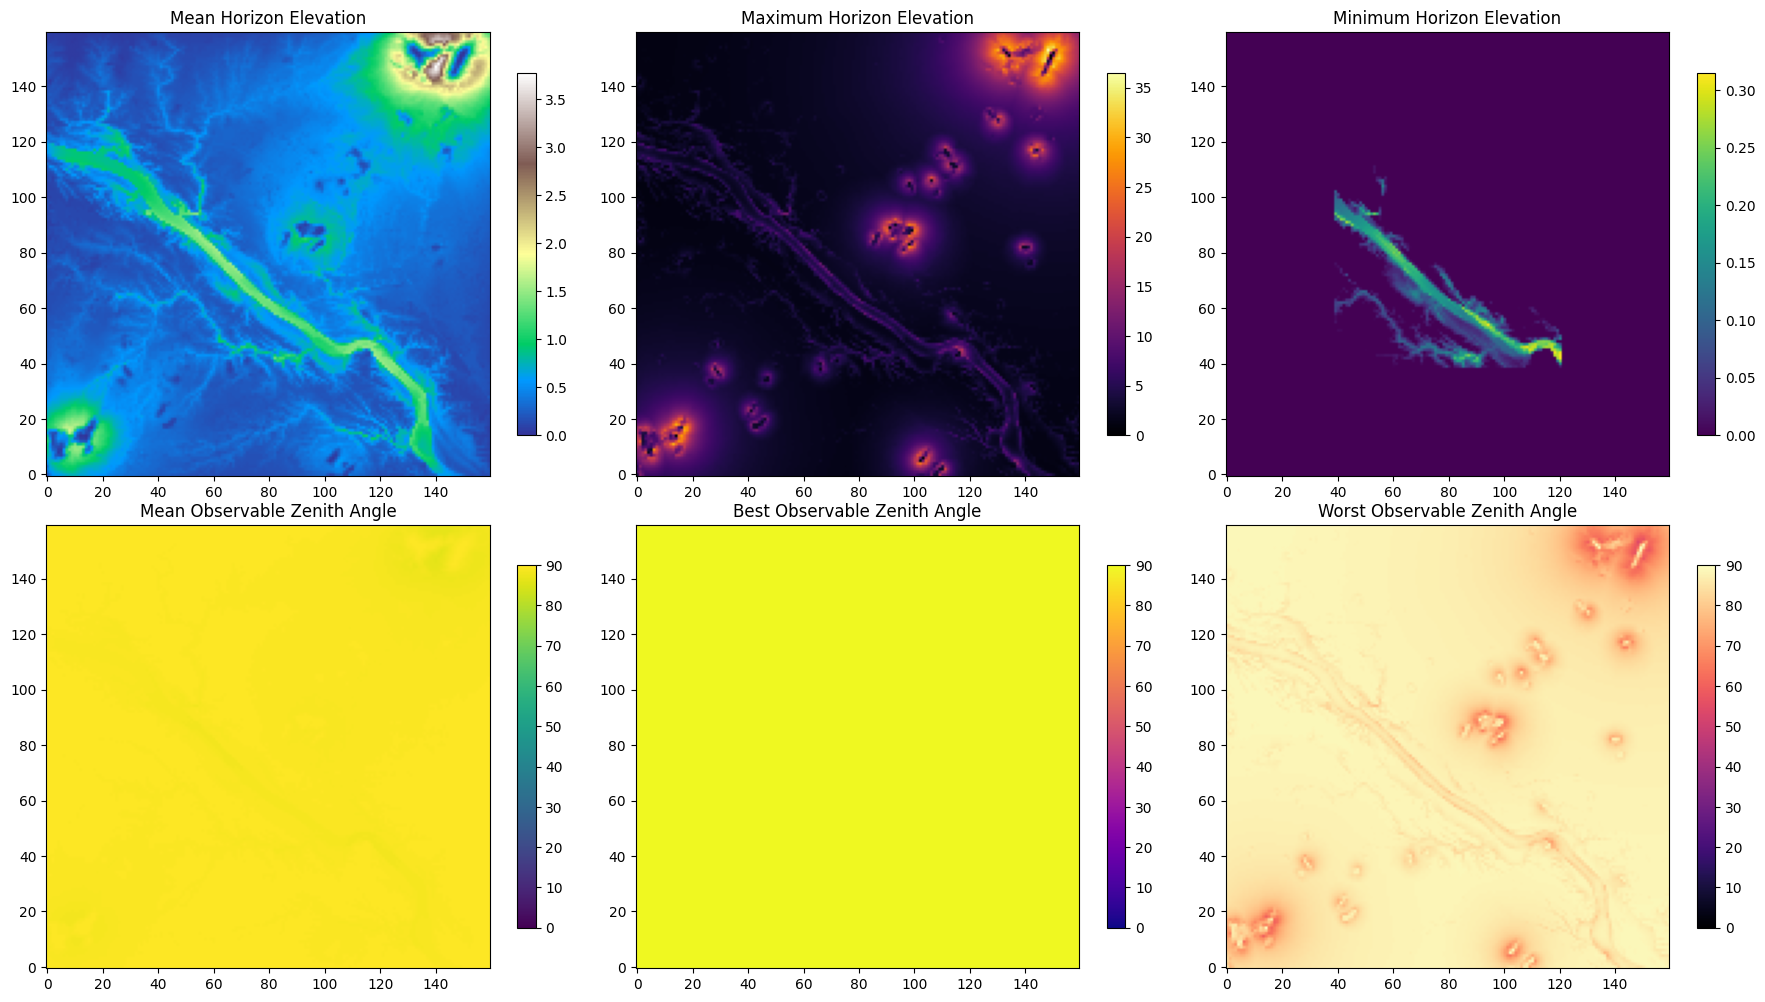

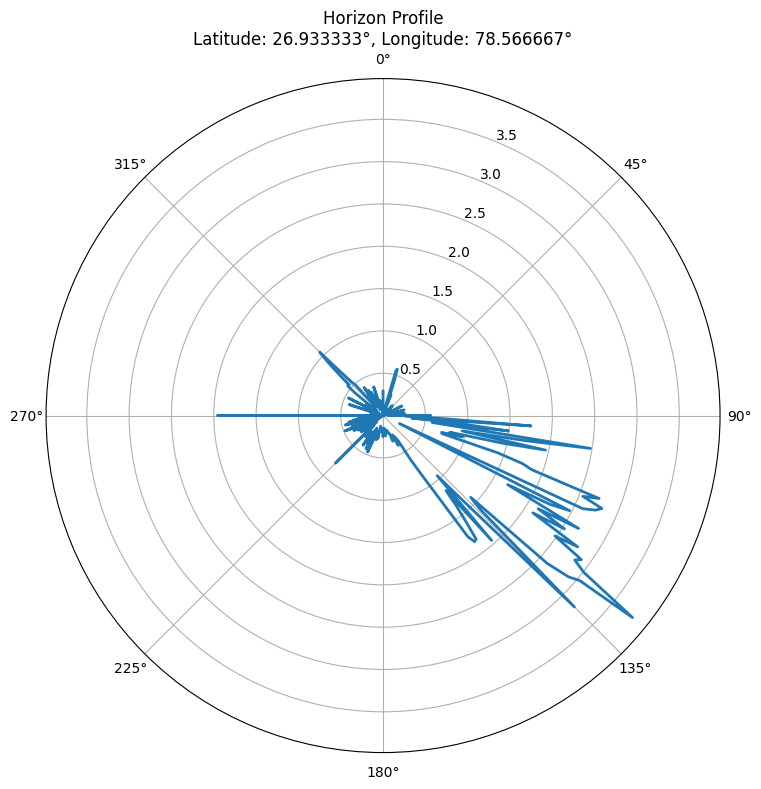

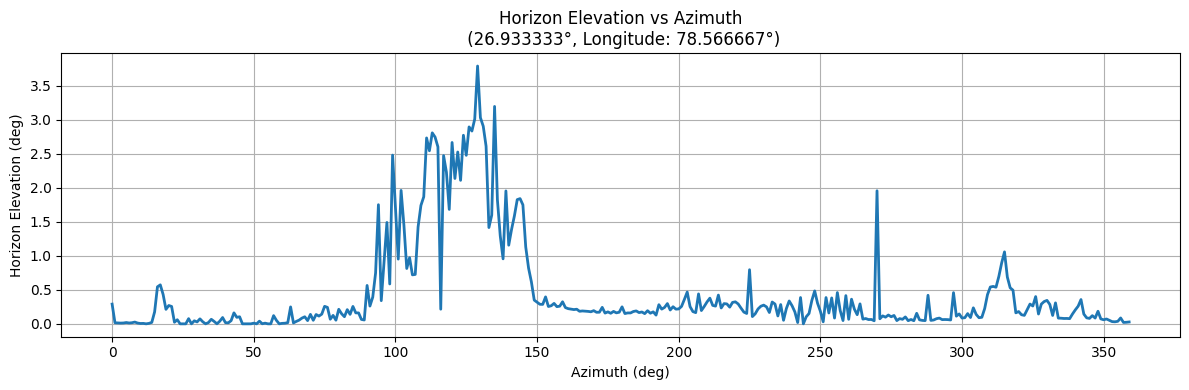

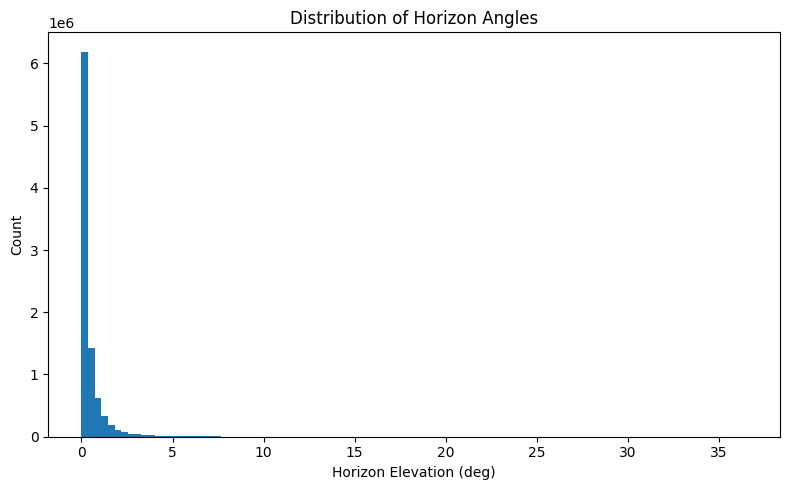

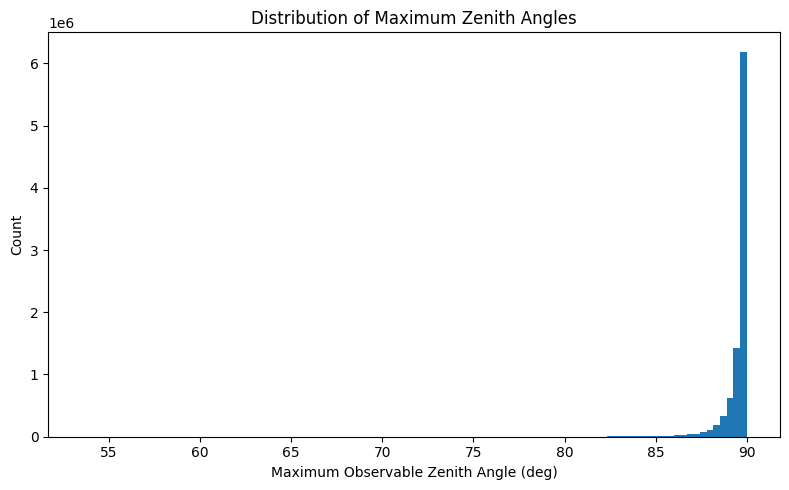

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# LOAD
# ==========================================================

OUT_DIR = r"C:\Users\Darkrai\Projects\iitk proj\horizon_out"

horizon = np.load(OUT_DIR + r"\horizon_elevation_deg.npy")
max_za  = np.load(OUT_DIR + r"\max_zenith_angle_deg.npy")

H, W, _ = horizon.shape

print("Horizon cube :", horizon.shape)
print("Max ZA cube  :", max_za.shape)

# ==========================================================
# DERIVED MAPS
# ==========================================================

mean_horizon = np.mean(horizon, axis=2)
max_horizon  = np.max(horizon, axis=2)
min_horizon  = np.min(horizon, axis=2)

mean_za = np.mean(max_za, axis=2)
best_za = np.max(max_za, axis=2)
worst_za = np.min(max_za, axis=2)

# ==========================================================
# PLOT MAPS
# ==========================================================

fig, ax = plt.subplots(2, 3, figsize=(18, 10))

# ----------------------------------------------------------

im = ax[0,0].imshow(
    mean_horizon,
    origin="lower",
    cmap="terrain"
)
ax[0,0].set_title("Mean Horizon Elevation")
plt.colorbar(im, ax=ax[0,0], shrink=0.8)

# ----------------------------------------------------------

im = ax[0,1].imshow(
    max_horizon,
    origin="lower",
    cmap="inferno"
)
ax[0,1].set_title("Maximum Horizon Elevation")
plt.colorbar(im, ax=ax[0,1], shrink=0.8)

# ----------------------------------------------------------

im = ax[0,2].imshow(
    min_horizon,
    origin="lower",
    cmap="viridis"
)
ax[0,2].set_title("Minimum Horizon Elevation")
plt.colorbar(im, ax=ax[0,2], shrink=0.8)

# ----------------------------------------------------------

im = ax[1,0].imshow(
    mean_za,
    origin="lower",
    cmap="viridis",
    vmin=0,
    vmax=90
)
ax[1,0].set_title("Mean Observable Zenith Angle")
plt.colorbar(im, ax=ax[1,0], shrink=0.8)

# ----------------------------------------------------------

im = ax[1,1].imshow(
    best_za,
    origin="lower",
    cmap="plasma",
    vmin=0,
    vmax=90
)
ax[1,1].set_title("Best Observable Zenith Angle")
plt.colorbar(im, ax=ax[1,1], shrink=0.8)

# ----------------------------------------------------------

im = ax[1,2].imshow(
    worst_za,
    origin="lower",
    cmap="magma",
    vmin=0,
    vmax=90
)
ax[1,2].set_title("Worst Observable Zenith Angle")
plt.colorbar(im, ax=ax[1,2], shrink=0.8)

plt.tight_layout()

# ==========================================================
# POLAR HORIZON PROFILE OF CENTRE PIXEL
# ==========================================================

fig = plt.figure(figsize=(8,8))
# ==========================================================
# CENTRE PIXEL COORDINATES
# ==========================================================

i = H // 2
j = W // 2

# Convert cropped DEM pixel back to geographic coordinates
lon, lat = rasterio.transform.xy(
    cropped_transform,
    i,
    j,
    offset="center"
)

theta = np.deg2rad(np.arange(360))

ax = plt.subplot(111, projection="polar")

ax.plot(theta, horizon[i, j], lw=2)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

ax.set_title(
    f"Horizon Profile\nLatitude: {lat:.6f}°, Longitude: {lon:.6f}°"
)

plt.tight_layout()

# ==========================================================
# LINE PROFILE OF CENTRE PIXEL
# ==========================================================

plt.figure(figsize=(12,4))

plt.plot(
    np.arange(360),
    horizon[i,j],
    lw=2
)

plt.grid(True)

plt.xlabel("Azimuth (deg)")
plt.ylabel("Horizon Elevation (deg)")

plt.title(f"Horizon Elevation vs Azimuth\n ({lat:.6f}°, Longitude: {lon:.6f}°)")

plt.tight_layout()

# ==========================================================
# HISTOGRAM OF ALL HORIZON ANGLES
# ==========================================================

plt.figure(figsize=(8,5))

plt.hist(
    horizon.ravel(),
    bins=100
)

plt.xlabel("Horizon Elevation (deg)")
plt.ylabel("Count")

plt.title("Distribution of Horizon Angles")

plt.tight_layout()

# ==========================================================
# HISTOGRAM OF ALL MAX ZENITH ANGLES
# ==========================================================

plt.figure(figsize=(8,5))

plt.hist(
    max_za.ravel(),
    bins=100
)

plt.xlabel("Maximum Observable Zenith Angle (deg)")
plt.ylabel("Count")

plt.title("Distribution of Maximum Zenith Angles")

plt.tight_layout()
# sns.heatmap(dem,cmap='terrain')
# ==========================================================
# SHOW EVERYTHING
# ==========================================================

plt.show()

In [108]:
import os
import numpy as np
import cupy as cp

# ==========================================================
# INPUTS
# ==========================================================

insert_idx = cp.asnumpy(insert_idx)

levels = meta["pressure_levels"].astype(np.float32) * 100.0  # Pa

outdir = r"C:\Users\Darkrai\Projects\iitk proj\amc_files"
os.makedirs(outdir, exist_ok=True)

timestep = 0

idx = insert_idx[timestep]

Ps = p_surface[timestep]
Ts = t_surface[timestep]
Qs = vmr_surface[timestep]

Tera = temp[timestep]
Qera = vmr[timestep]

H, W = Ps.shape

# ==========================================================
# BUILD ATMOSPHERES
# ==========================================================

# columns:
# 0      -> insertion index
# 1:15   -> pressure
# 15:29  -> temperature
# 29:43  -> vmr

profiles = np.empty((H * W, 43), dtype=np.float32)

k = 0

for i in range(H):
    for j in range(W):

        ins = int(idx[i, j])

        p = np.insert(levels, ins, Ps[i, j])
        t = np.insert(Tera,  ins, Ts[i, j])
        q = np.insert(Qera,  ins, Qs[i, j])

        profiles[k, 0] = ins
        profiles[k, 1:15] = p
        profiles[k,15:29] = t
        profiles[k,29:43] = q

        k += 1

# ==========================================================
# QUANTISATION
# ==========================================================

Pstep = 50.0
Tstep = 0.05
Qstep = 5e-6

profiles[:,1:15]  = np.round(profiles[:,1:15]  / Pstep) * Pstep
profiles[:,15:29] = np.round(profiles[:,15:29] / Tstep) * Tstep
profiles[:,29:43] = np.round(profiles[:,29:43] / Qstep) * Qstep

# ==========================================================
# UNIQUE ATMOSPHERES
# ==========================================================

unique_profiles, inverse = np.unique(
    profiles,
    axis=0,
    return_inverse=True
)

print("="*60)
print("Pixels     :", H*W)
print("Unique     :", len(unique_profiles))
print("Reduction  :", (H*W)/len(unique_profiles))
print("="*60)

np.save(
    os.path.join(outdir, "pixel_to_profile.npy"),
    inverse.reshape(H, W)
)

# ==========================================================
# WRITE AMC FILES
# ==========================================================

for n, prof in enumerate(unique_profiles):

    ins = int(prof[0])

    P = prof[1:15]
    T = prof[15:29]
    Q = prof[29:43]

    filename = os.path.join(outdir, f"atm_{n:06d}.amc")

    with open(filename, "w") as f:

        f.write("f 2 GHz 14 GHz 0.01 GHz\n")
        f.write("output f GHz tx Tb K\n")
        f.write("T0 2.7 K\n")
        f.write("za 0 deg\n\n")

        P_use = P[ins:]
        T_use = T[ins:]
        Q_use = Q[ins:]

        for p, t, q in zip(P_use[::-1], T_use[::-1], Q_use[::-1]):

            f.write("layer\n")
            f.write(f"Pbase {p:.1f} Pa\n")
            f.write(f"Tbase {t:.6f} K\n")
            f.write("column dry_air hydrostatic\n")
            f.write(f"column h2o vmr {q:.10e}\n\n")

print(f"\nWritten {len(unique_profiles)} AMC files.")

Pixels     : 25600
Unique     : 403
Reduction  : 63.52357320099256

Written 403 AMC files.
